In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Imports                                            ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/engineered_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (5600, 19)


,failed_connection_attempts,packets_sent_per_sec,packets_recv_per_sec,tcp_connection_count,context_switch_rate,unique_dst_port_count,top_process_cpu_pct,cpu_user_pct,load_avg_1m,attack_type,is_attack,packet_rate_total,packet_spike_ratio,connection_spike_ratio,cpu_spike_ratio,process_cpu_ratio,failure_rate,port_scan_intensity,load_per_connection
0,0.0,0.0,0.0,9.0,567.0,0,0.0,6.21,0.18,crypto,1,0.0,1.002004,1.000000,1.000000,0.000000,0.0,0.0,0.018000
1,0.0,0.0,0.0,9.0,803.0,0,0.0,1.50,0.41,crypto,1,0.0,1.002004,1.000000,0.389105,0.000000,0.0,0.0,0.041000
2,0.0,0.0,0.0,10.0,893.0,0,0.0,5.68,0.41,crypto,1,0.0,1.002004,1.071429,1.272591,0.000000,0.0,0.0,0.037273
3,0.0,0.0,0.0,14.0,404.0,0,26.0,4.99,0.41,crypto,1,0.0,1.002004,1.333333,1.085963,5.210410,0.0,0.0,0.027333
4,0.0,0.0,0.0,14.0,496.0,0,59.9,2.17,0.37,crypto,1,0.0,1.002004,1.250000,0.527981,27.603559,0.0,0.0,0.024667


In [3]:
features = [
    'failure_rate',
    'port_scan_intensity',
    'process_cpu_ratio',
    'packet_spike_ratio',
    'connection_spike_ratio',
    'cpu_spike_ratio'
]

X = df[features]
y = df['is_attack']

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Preprocessing                                     ║
# ╚══════════════════════════════════════════════════════════╝

# Fix inf/nan
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Log transform
for col in ['process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio']:
    df[col] = np.log1p(df[col])

# Recreate X after transformation
X = df[features]

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Train/Test Split (Normal Only Training)            ║
# ╚══════════════════════════════════════════════════════════╝

X_train = X[y == 0]
X_test = X

In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Scaling                                           ║
# ╚══════════════════════════════════════════════════════════╝

# Remove zero variance
zero_var_cols = X_train.columns[X_train.std() == 0]

print("Dropping:", list(zero_var_cols))

X_train = X_train.drop(columns=zero_var_cols)
X_test = X_test.drop(columns=zero_var_cols)

# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dropping: ['failure_rate']


In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Train Model                                       ║
# ╚══════════════════════════════════════════════════════════╝

model = IsolationForest(
    n_estimators=200,
    contamination=0.28,
    random_state=42
)

model.fit(X_train_scaled)

print("Model trained")

Model trained


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Predictions                                       ║
# ╚══════════════════════════════════════════════════════════╝

preds = model.predict(X_test_scaled)

# Convert to 0/1
preds = np.where(preds == 1, 0, 1)

df['anomaly_pred'] = preds

In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Detection per Attack Type                         ║
# ╚══════════════════════════════════════════════════════════╝

detection_rates = df.groupby('attack_type')['anomaly_pred'].mean()

print("Detection Rate per Attack Type:\n")
print(detection_rates)

Detection Rate per Attack Type:

attack_type
crypto      0.996000
ddos        0.928333
none        0.280000
portscan    1.000000
Name: anomaly_pred, dtype: float64


In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Counts Table                                      ║
# ╚══════════════════════════════════════════════════════════╝

counts = df.groupby(['attack_type', 'anomaly_pred']).size().unstack(fill_value=0)

counts

anomaly_pred,0,1
attack_type,,
crypto,2,498
ddos,43,557
none,2808,1092
portscan,0,600


C:\Users\to_ro\AppData\Local\Temp\ipykernel_31116\4122752941.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


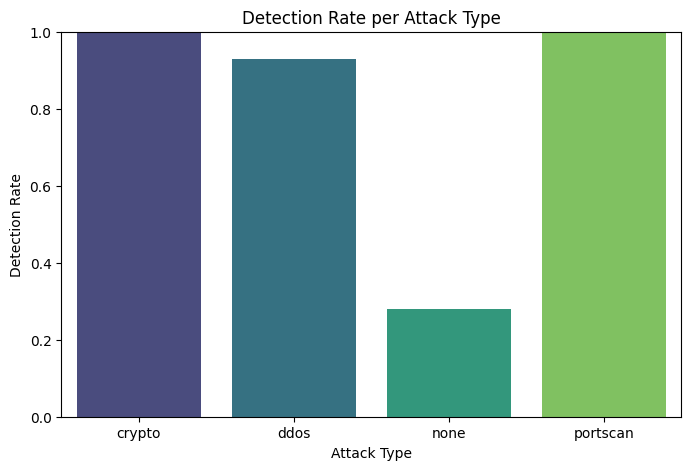

In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Visualization                                     ║
# ╚══════════════════════════════════════════════════════════╝

plt.figure(figsize=(8,5))

sns.barplot(
    x=detection_rates.index,
    y=detection_rates.values,
    palette='viridis'
)

plt.title("Detection Rate per Attack Type")
plt.ylabel("Detection Rate")
plt.xlabel("Attack Type")
plt.ylim(0, 1)

plt.show()

In [12]:
# ╔══════════════════════════════════════════════════════════╗
# ║      False Positive Analysis                           ║
# ╚══════════════════════════════════════════════════════════╝

normal_fp_rate = df[df['attack_type'] == 'none']['anomaly_pred'].mean()

print(f"False Positive Rate (Normal flagged as anomaly): {normal_fp_rate:.3f}")

False Positive Rate (Normal flagged as anomaly): 0.280


In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║      Final Insights                                    ║
# ╚══════════════════════════════════════════════════════════╝

print("Key Observations:\n")

print("- Crypto attacks show near-perfect detection due to extreme CPU usage patterns")
print("- Portscan attacks are highly separable due to port diversity features")
print("- DDoS shows strong but not perfect detection due to overlap with high normal traffic")
print("- Some normal samples are flagged as anomalies, leading to false positives")

print("\nConclusion:")
print("Anomaly detection performs best for extreme behaviors and moderately for overlapping patterns.")

Key Observations:

- Crypto attacks show near-perfect detection due to extreme CPU usage patterns
- Portscan attacks are highly separable due to port diversity features
- DDoS shows strong but not perfect detection due to overlap with high normal traffic
- Some normal samples are flagged as anomalies, leading to false positives

Conclusion:
Anomaly detection performs best for extreme behaviors and moderately for overlapping patterns.
